# VLM-based Military Aircraft Classification

This notebook classifies military aircraft crops from the **military-aircraft-recognition-dataset** using a Vision Language Model (VLM) running locally in **LM Studio**.

## Dataset
- 3 842 aerial images, 20 aircraft classes (A1â€“A20)
- Labels: YOLO Oriented Bounding Box format (rotated boxes around each aircraft)
- Split: 80 % train / 10 % validation / 10 % test

## Three classification strategies compared
| # | Strategy | How it works |
|---|---|---|
| 1 | **Description + TF-IDF** | VLM describes each crop in text; nearest class found via cosine similarity |
| 2 | **Few-shot (1 crop)** | VLM sees one labeled reference image per class, then classifies directly |
| 3 | **Few-shot (3-crop collage)** | Same but each reference is a side-by-side tiling of 3 training crops |

## 1  Setup

In [1]:
import base64, json, re
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# Paths 
DATA_DIR   = Path("ba_military_aircraft_detection/data")
CACHE_FILE = Path("vlm_index.json")          # description index
RES_DESC   = Path("vlm_results.json")         # description + TF-IDF results
RES_FS1    = Path("vlm_results_fewshot.json") # few-shot 1 crop
RES_FS3    = Path("vlm_results_collage.json") # few-shot 3-crop collage

# Constants
CLASSES    = [f"A{i}" for i in range(1, 21)]
MIN_CROP   = 32     # px skip crops smaller than this
COLLAGE_SZ = 96     # px each cell in a collage
LM_URL     = "http://localhost:1234/v1"

client = OpenAI(base_url=LM_URL, api_key="lm-studio")

In [2]:
# Verify LM Studio is reachable
models = client.models.list().data
if not models:
    raise RuntimeError("No model loaded in LM Studio, load a vision model first.")
MODEL = models[0].id
print(f"Connected  : {LM_URL}")
print(f"Active model: {MODEL}")

Connected  : http://localhost:1234/v1
Active model: zai-org/glm-4.6v-flash


## 2  Image & label helpers

Each label file contains one line per aircraft:
```
class_idx  x1 y1  x2 y2  x3 y3  x4 y4   (normalised corner coords)
```
We convert the four corners back to pixel coordinates and use `cv2.warpPerspective` to deskew the rotated bounding box into an upright crop.

In [3]:
def parse_label_file(path: Path, w: int, h: int) -> list[tuple[int, np.ndarray]]:
    """Return (class_idx, 4Ã—2 pixel coords) for every object in a label file."""
    objects = []
    for line in path.read_text().splitlines():
        parts = line.split()
        if len(parts) != 9:
            continue
        ci  = int(parts[0])
        raw = list(map(float, parts[1:]))
        pts = np.array(
            [[raw[i] * w, raw[i + 1] * h] for i in range(0, 8, 2)],
            dtype=np.float32,
        )
        objects.append((ci, pts))
    return objects


def crop_obb(img: np.ndarray, pts: np.ndarray) -> np.ndarray | None:
    """Deskew a rotated bounding box into an upright rectangle."""
    rect       = cv2.minAreaRect(pts)
    bw, bh     = int(rect[1][0]), int(rect[1][1])
    if min(bw, bh) < MIN_CROP:
        return None
    box = cv2.boxPoints(rect).astype(np.float32)
    dst = np.array([[0, bh-1],[0, 0],[bw-1, 0],[bw-1, bh-1]], dtype=np.float32)
    return cv2.warpPerspective(img, cv2.getPerspectiveTransform(box, dst), (bw, bh))


def iter_crops(split_dir: Path):
    """Yield (class_idx, crop_bgr, image_name) for every valid object in a split."""
    imgs_dir, lbl_dir = split_dir / "images", split_dir / "labels"
    for img_path in sorted(imgs_dir.glob("*.*")):
        lbl = lbl_dir / (img_path.stem + ".txt")
        if not lbl.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        for ci, pts in parse_label_file(lbl, w, h):
            crop = crop_obb(img, pts)
            if crop is not None:
                yield ci, crop, img_path.name


def img_to_data_url(bgr: np.ndarray) -> str:
    """Encode a BGR numpy array as a base64 JPEG data URL for the API."""
    _, buf = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])
    return "data:image/jpeg;base64," + base64.b64encode(buf).decode()


def show_bgr(ax, img, title=""):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")

### 2.1  Dataset preview
One example crop per class from the training set.

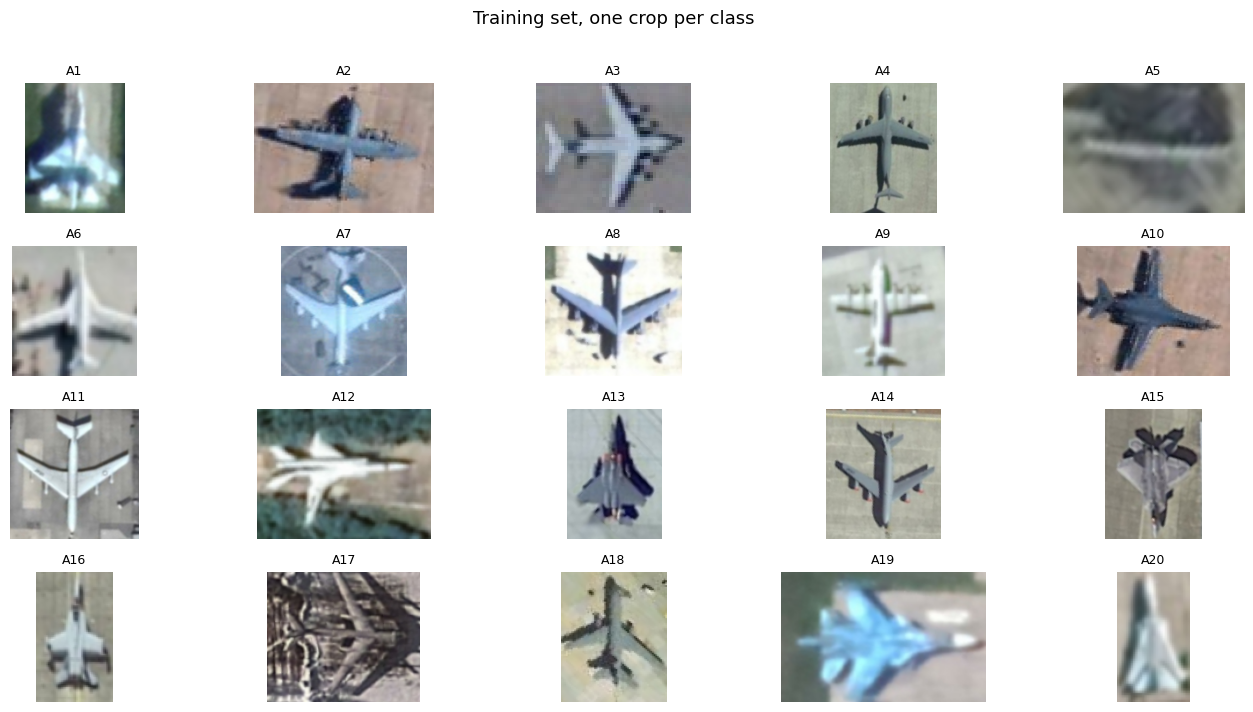

In [5]:
# Collect one example crop per class
examples: dict[str, np.ndarray] = {}
for ci, crop, _ in iter_crops(DATA_DIR / "train"):
    cls = CLASSES[ci]
    if cls not in examples:
        examples[cls] = crop
    if len(examples) == len(CLASSES):
        break

fig, axes = plt.subplots(4, 5, figsize=(14, 7))
for ax, cls in zip(axes.flat, CLASSES):
    if cls in examples:
        show_bgr(ax, examples[cls], cls)
    else:
        ax.axis("off")
fig.suptitle("Training set, one crop per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3  Strategy 1 â€” Description + TF-IDF

**Idea:** Use the VLM as a visual feature extractor.

1. **Index phase** â€” for each training crop, ask the VLM to describe the aircraft in text. Cache N descriptions per class.
2. **Classify phase** â€” for each test crop, get a VLM description, then rank all 20 class profiles by TF-IDF cosine similarity.

This works even when the VLM has no prior knowledge of the A1â€“A20 label scheme.

In [ ]:
DESCRIBE_PROMPT = (
    "Describe the military aircraft in this image. "
    "Focus on wing shape and configuration, fuselage design, number of engines, "
    "tail design, and any distinctive visual features. "
    "Be concise (2-3 sentences)."
)

def describe_crop(crop: np.ndarray) -> str:
    """Ask the VLM to describe one aircraft crop; handles reasoning-only models."""
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": [
            {"type": "text",      "text": DESCRIBE_PROMPT},
            {"type": "image_url", "image_url": {"url": img_to_data_url(crop)}},
        ]}],
        max_tokens=2048,
        temperature=0.0,
    )
    msg     = resp.choices[0].message
    content = (msg.content or "").strip()
    if not content:           # reasoning model: answer is inside reasoning_content
        content = (msg.model_dump().get("reasoning_content") or "").strip()
    return content


def nearest_class(description: str, index: dict[str, list[str]]) -> str:
    """Find the class whose cached descriptions are most similar to the given text."""
    classes    = [c for c, descs in index.items() if descs]
    class_docs = [" ".join(index[c]) for c in classes]
    corpus     = [description] + class_docs
    tfidf = TfidfVectorizer(ngram_range=(1, 2)).fit_transform(corpus)
    sims  = cosine_similarity(tfidf[0:1], tfidf[1:])[0]
    return classes[int(np.argmax(sims))]

### 3.1  Build (or load) the description index

In [ ]:
N_PER_CLASS = 5   # training descriptions to cache per class

def build_index(n: int = N_PER_CLASS) -> dict[str, list[str]]:
    index: dict[str, list[str]] = {c: [] for c in CLASSES}
    if CACHE_FILE.exists():
        saved = json.loads(CACHE_FILE.read_text())
        for c, descs in saved.items():
            if c in index:
                index[c] = [d for d in descs if d]   # drop empty entries
        already = sum(len(v) for v in index.values())
        print(f"Loaded {already} cached descriptions from {CACHE_FILE}")

    need = sum(max(0, n - len(index[c])) for c in CLASSES)
    if need == 0:
        print("Index already complete.")
        return index

    print(f"Generating {need} new descriptions...")
    for ci, crop, img_name in tqdm(iter_crops(DATA_DIR / "train"), desc="Indexing"):
        cls = CLASSES[ci]
        if len(index[cls]) >= n:
            continue
        try:
            index[cls].append(describe_crop(crop))
            CACHE_FILE.write_text(json.dumps(index, indent=2))
        except Exception as e:
            print(f"Error ({img_name}): {e}")
        if all(len(index[c]) >= n for c in CLASSES):
            break
    return index

index = build_index()

### 3.2  Inspect cached descriptions

In [ ]:
# Show one example description per class
for cls in CLASSES:
    descs = index.get(cls, [])
    preview = descs[0][:120] + "..." if descs else "(none)"
    print(f"{cls:4s}: {preview}")

In [ ]:
# Visualise one crop alongside its cached description
demo_class = "A13"
demo_crop  = examples.get(demo_class)
demo_desc  = (index.get(demo_class) or [""])[0]

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
show_bgr(ax, demo_crop, demo_class)
fig.text(0.5, -0.02, demo_desc, ha="center", va="top", wrap=True,
         fontsize=8, style="italic", transform=fig.transFigure)
plt.tight_layout()
plt.show()

### 3.3  Classify test crops (or load saved results)

In [ ]:
def classify_description(split: str = "test", max_samples: int | None = 200) -> list[dict]:
    """Run description + TF-IDF classification. Loads saved results if available."""
    if RES_DESC.exists():
        print(f"Loading saved results from {RES_DESC}")
        return json.loads(RES_DESC.read_text())["results"]

    all_crops = list(iter_crops(DATA_DIR / split))
    if max_samples:
        step = max(1, len(all_crops) // max_samples)
        all_crops = all_crops[::step][:max_samples]

    results, correct, total = [], 0, 0
    for ci, crop, img_name in tqdm(all_crops, desc="Classifying (description)"):
        gt = CLASSES[ci]
        try:
            desc = describe_crop(crop)
            pred = nearest_class(desc, index)
            ok   = pred == gt
            correct += ok; total += 1
            results.append({"image": img_name, "gt": gt, "pred": pred, "ok": ok, "desc": desc})
        except Exception as e:
            print(f"Error ({img_name}): {e}")

    out = {"accuracy": correct/total if total else 0, "correct": correct,
           "total": total, "split": split, "results": results}
    RES_DESC.write_text(json.dumps(out, indent=2))
    print(f"Accuracy: {correct}/{total} = {correct/total:.2%}")
    return results

results_desc = classify_description()

## 4  Strategy 2 â€” Few-shot: direct label output

**Idea:** Skip the text-matching step entirely.

For each test crop we build a single API call containing:
- 20 labeled reference images (one per class)
- The test crop

The model is asked to output **only the class label**.

### 4.1  Single-crop references

Loaded single-crop refs for 20/20 classes


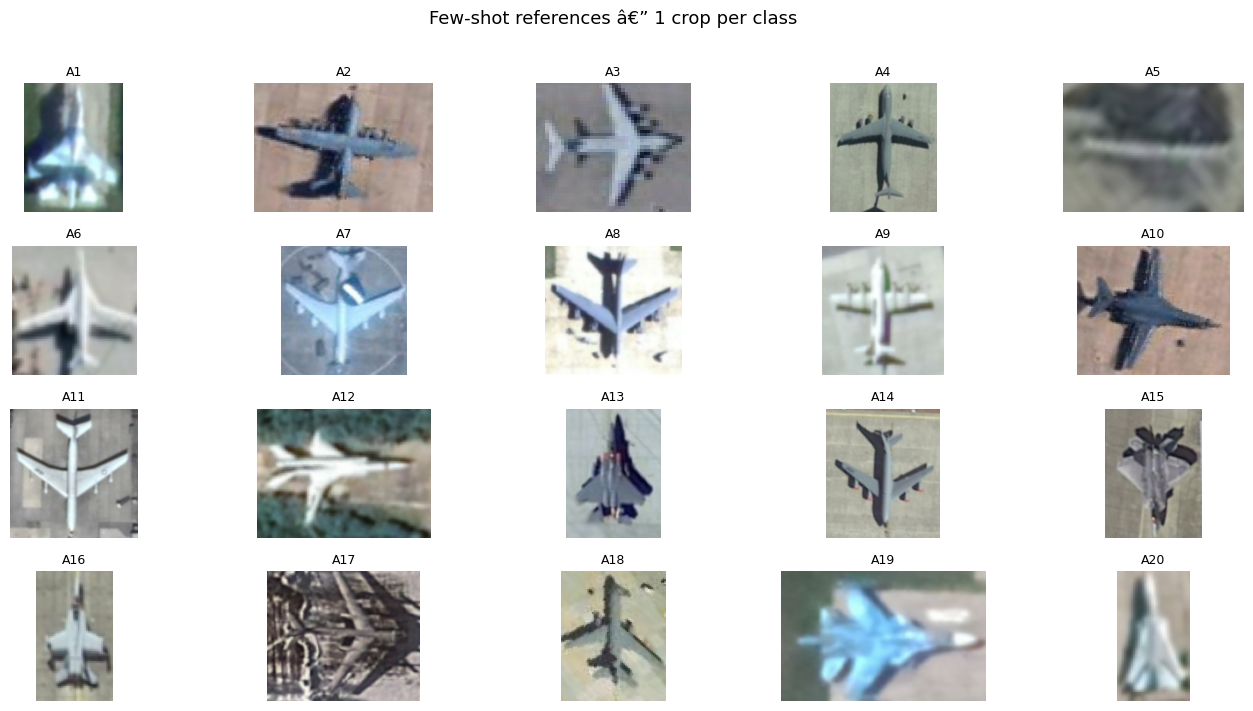

In [6]:
def load_refs_single(n_crops: int = 1) -> dict[str, np.ndarray | None]:
    """One representative crop per class from the training split."""
    buckets: dict[str, list[np.ndarray]] = {c: [] for c in CLASSES}
    for ci, crop, _ in iter_crops(DATA_DIR / "train"):
        cls = CLASSES[ci]
        if len(buckets[cls]) < n_crops:
            buckets[cls].append(crop)
        if all(len(v) >= n_crops for v in buckets.values()):
            break
    return {cls: crops[0] if crops else None for cls, crops in buckets.items()}

refs_single = load_refs_single()
print(f"Loaded single-crop refs for {sum(v is not None for v in refs_single.values())}/20 classes")

# Preview
fig, axes = plt.subplots(4, 5, figsize=(14, 7))
for ax, cls in zip(axes.flat, CLASSES):
    crop = refs_single.get(cls)
    show_bgr(ax, crop, cls) if crop is not None else ax.axis("off")
fig.suptitle("Few-shot references â€” 1 crop per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2  3-crop collage references

Instead of a single reference per class we tile 3 crops side-by-side.
The total number of API images stays at 21 (20 class refs + 1 test), but each class ref now shows more visual variety.

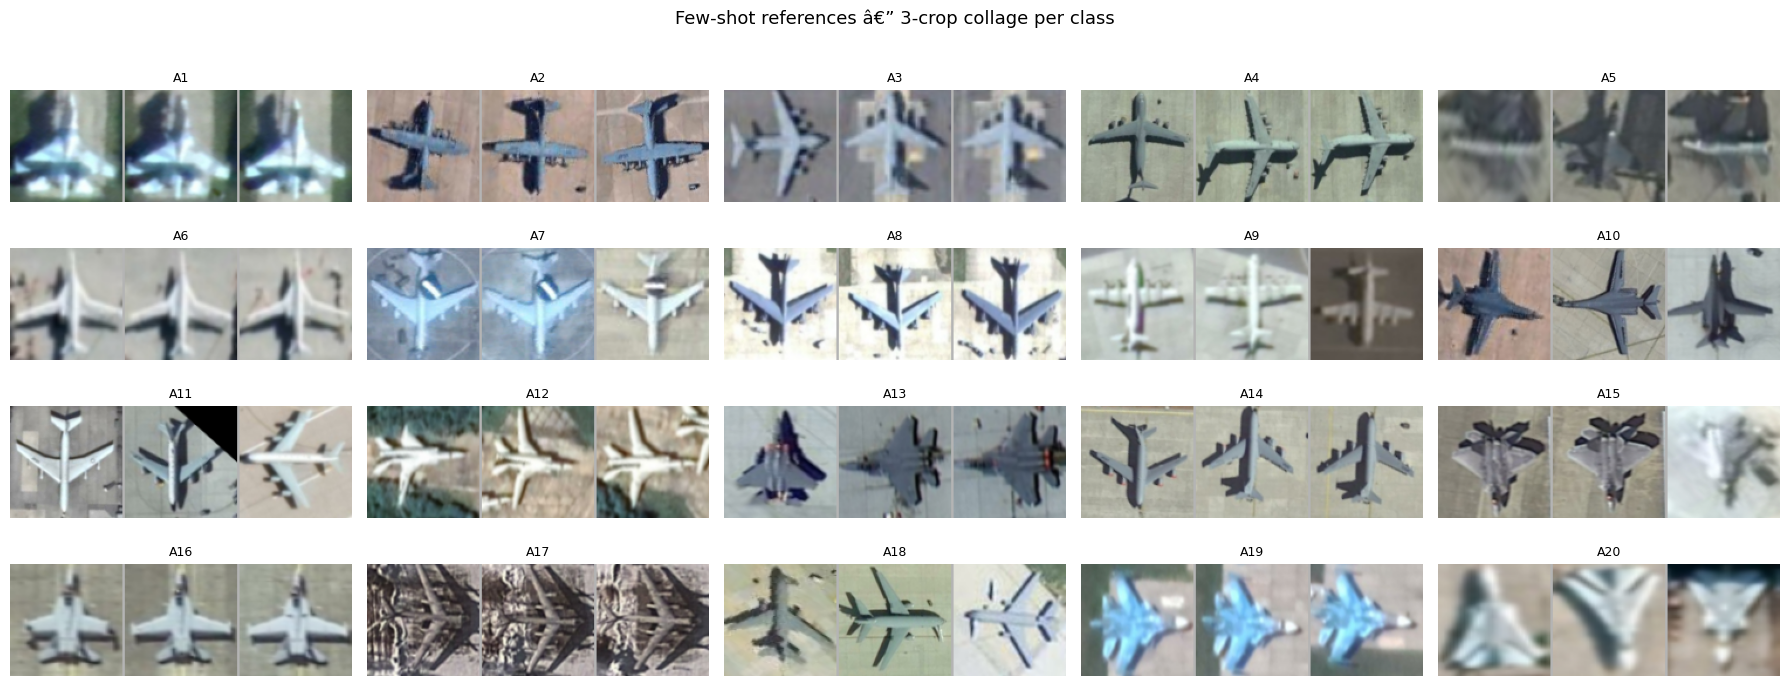

In [12]:
def make_collage(crops: list[np.ndarray], cell: int = COLLAGE_SZ) -> np.ndarray:
    """Tile crops horizontally with a 2-px grey separator."""
    cells = [cv2.resize(c, (cell, cell)) for c in crops]
    sep   = np.full((cell, 2, 3), 180, dtype=np.uint8)
    parts = []
    for i, c in enumerate(cells):
        if i: parts.append(sep)
        parts.append(c)
    return np.hstack(parts)


def load_refs_collage(n_crops: int = 3) -> dict[str, np.ndarray | None]:
    """n_crops-wide collage per class from the training split."""
    buckets: dict[str, list[np.ndarray]] = {c: [] for c in CLASSES}
    for ci, crop, _ in iter_crops(DATA_DIR / "train"):
        cls = CLASSES[ci]
        if len(buckets[cls]) < n_crops:
            buckets[cls].append(crop)
        if all(len(v) >= n_crops for v in buckets.values()):
            break
    return {cls: make_collage(crops) if crops else None
            for cls, crops in buckets.items()}

refs_collage = load_refs_collage()

# Preview
fig, axes = plt.subplots(4, 5, figsize=(18, 7))
for ax, cls in zip(axes.flat, CLASSES):
    col = refs_collage.get(cls)
    show_bgr(ax, col, cls) if col is not None else ax.axis("off")
fig.suptitle("Few-shot references â€” 3-crop collage per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.3  Few-shot classification function

In [13]:
def extract_label(text: str) -> str:
    """Pull the first A1-A20 token out of a VLM response."""
    m = re.search(r'\bA(1[0-9]|20|[1-9])\b', text, re.IGNORECASE)
    return m.group(0).upper() if m else ""


def classify_few_shot_single(test_crop: np.ndarray, refs: dict) -> str:
    """20 labeled refs + test crop -> class label (one API call)."""
    content = [{"type": "text",
                "text": "Reference images for each aircraft class:"}]
    for cls in CLASSES:
        ref = refs.get(cls)
        if ref is None: continue
        content += [
            {"type": "text",      "text": f"{cls}:"},
            {"type": "image_url", "image_url": {"url": img_to_data_url(ref)}},
        ]
    content += [
        {"type": "text",
         "text": ("Which of the 20 classes above does this aircraft belong to? "
                  "Reply with ONLY the class label (e.g. A1, A7, A14).")},
        {"type": "image_url", "image_url": {"url": img_to_data_url(test_crop)}},
    ]
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": content}],
        max_tokens=2048, temperature=0.0,
    )
    msg    = resp.choices[0].message
    answer = (msg.content or "").strip()
    if not answer:
        answer = (msg.model_dump().get("reasoning_content") or "").strip()
    return extract_label(answer)

### 4.4  Run few-shot (or load saved results)

In [14]:
def run_few_shot(refs, result_path: Path, split="test", max_samples=200) -> list[dict]:
    if result_path.exists():
        print(f"Loading saved results from {result_path}")
        return json.loads(result_path.read_text())["results"]

    all_crops = list(iter_crops(DATA_DIR / split))
    if max_samples:
        step = max(1, len(all_crops) // max_samples)
        all_crops = all_crops[::step][:max_samples]

    results, correct, total = [], 0, 0
    for ci, crop, img_name in tqdm(all_crops, desc=f"Classifying few-shot ({result_path.stem})"):
        gt = CLASSES[ci]
        try:
            pred = classify_few_shot_single(crop, refs)
            ok   = pred == gt
            correct += ok; total += 1
            results.append({"image": img_name, "gt": gt, "pred": pred, "ok": ok})
        except Exception as e:
            print(f"Error ({img_name}): {e}")

    out = {"accuracy": correct/total if total else 0, "correct": correct,
           "total": total, "split": split, "results": results}
    result_path.write_text(json.dumps(out, indent=2))
    print(f"Accuracy: {correct}/{total} = {correct/total:.2%}")
    return results

# Single-crop few-shot
results_fs1 = run_few_shot(refs_single,  RES_FS1)
# 3-crop collage few-shot
results_fs3 = run_few_shot(refs_collage, RES_FS3)

Loading saved results from vlm_results_fewshot.json
Loading saved results from vlm_results_collage.json


## 5  Results & Comparison

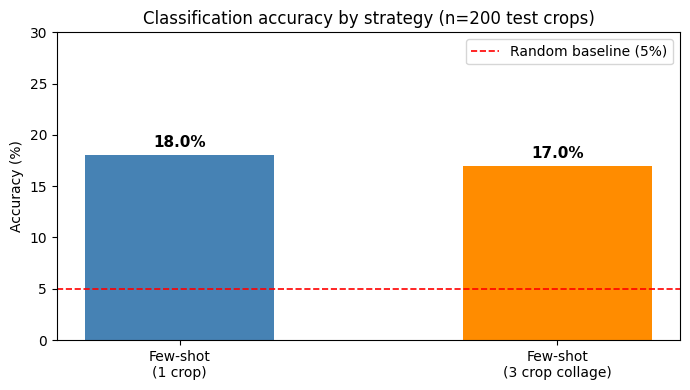

In [23]:
def accuracy(results: list[dict]) -> float:
    return sum(r["ok"] for r in results) / len(results) if results else 0.0

accs = {
    #"Description\n+ TF-IDF": accuracy(results_desc),
    "Few-shot\n(1 crop)": accuracy(results_fs1),
    "Few-shot\n(3 crop collage)": accuracy(results_fs3),
}
random_baseline = 1 / len(CLASSES)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(accs.keys(), [v * 100 for v in accs.values()],
              color=["steelblue", "darkorange", "seagreen"], width=0.5)
ax.axhline(random_baseline * 100, color="red", linestyle="--", linewidth=1.2,
           label=f"Random baseline ({random_baseline:.0%})")
for bar, val in zip(bars, accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Classification accuracy by strategy (n=200 test crops)")
ax.set_ylim(0, 30)
ax.legend()
plt.tight_layout()
plt.show()

### 5.1  Per-class accuracy

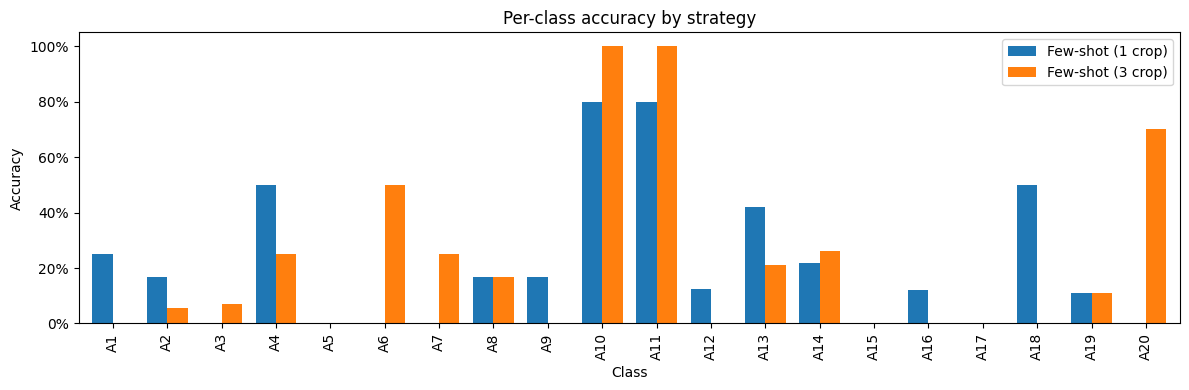

In [22]:
def per_class_acc(results: list[dict]) -> pd.Series:
    df = pd.DataFrame(results)
    return df.groupby("gt")["ok"].mean().reindex(CLASSES).fillna(0)

#pa_desc = per_class_acc(results_desc)
pa_fs1  = per_class_acc(results_fs1)
pa_fs3  = per_class_acc(results_fs3)

df_pa = pd.DataFrame({
    #"Description + TF-IDF": pa_desc,
    "Few-shot (1 crop)":    pa_fs1,
    "Few-shot (3 crop)": pa_fs3,
}, index=CLASSES)

fig, ax = plt.subplots(figsize=(12, 4))
df_pa.plot(kind="bar", ax=ax, width=0.75)
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class accuracy by strategy")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5.2  Confusion matrix best strategy

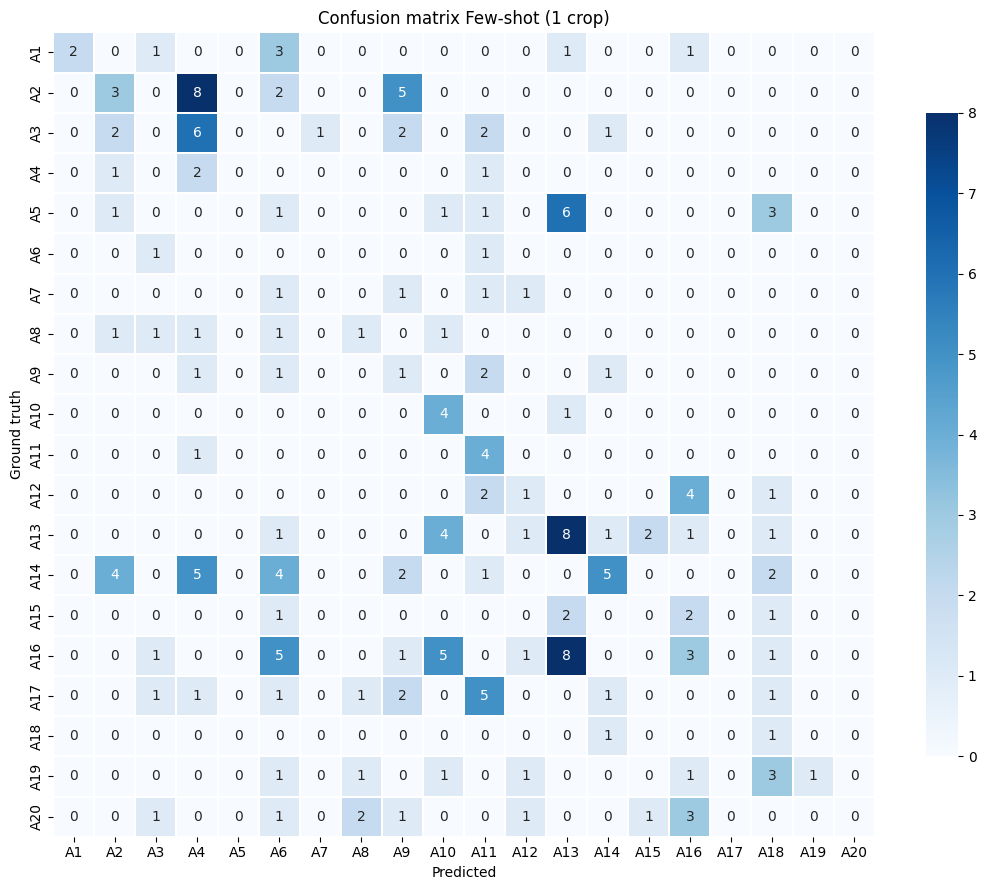

In [21]:
def plot_confusion(results: list[dict], title: str) -> None:
    df   = pd.DataFrame(results).dropna(subset=["pred"])
    df   = df[df["pred"].isin(CLASSES)]
    cm   = confusion_matrix(df["gt"], df["pred"], labels=CLASSES)
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.3,
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(results_fs1, "Confusion matrix Few-shot (1 crop)")

### 5.3  Qualitative inspection correct vs incorrect predictions

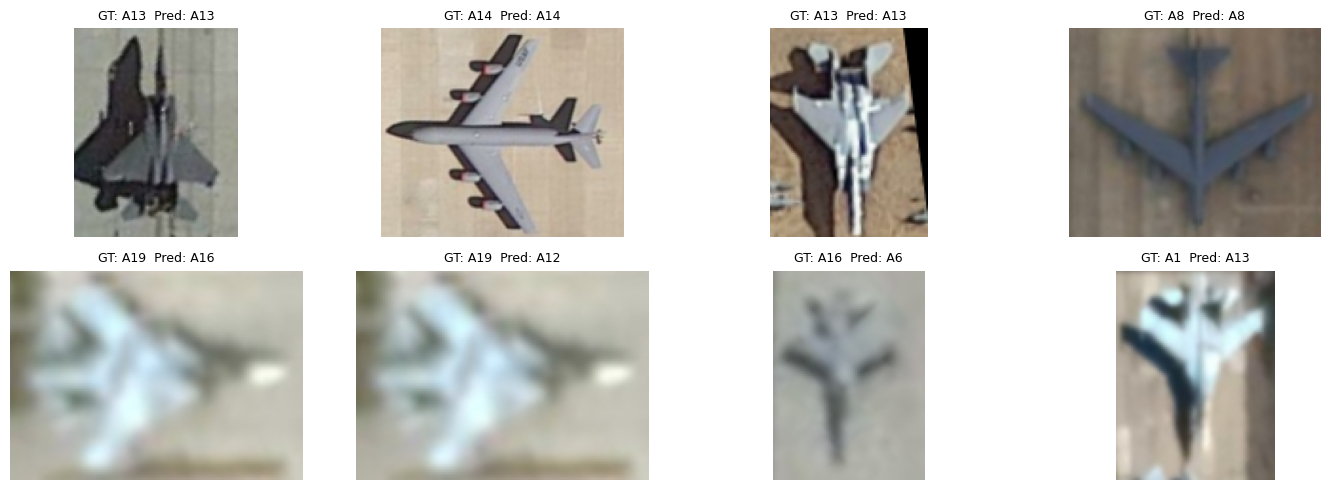

In [20]:
def show_predictions(results: list[dict], n_correct=4, n_wrong=4) -> None:
    """Display sample correct and incorrect predictions side by side."""
    imgs_dir = DATA_DIR / "test" / "images"
    lbl_dir  = DATA_DIR / "test" / "labels"

    correct = [r for r in results if r["ok"]][:n_correct]
    wrong   = [r for r in results if not r["ok"] and r.get("pred")][:n_wrong]
    rows    = [correct, wrong]
    titles  = ["Correct predictions", "Incorrect predictions"]

    fig, axes = plt.subplots(2, max(n_correct, n_wrong), figsize=(14, 5))
    for row_i, (row_results, row_title) in enumerate(zip(rows, titles)):
        axes[row_i, 0].set_ylabel(row_title, fontsize=10, labelpad=8)
        for col_i in range(max(n_correct, n_wrong)):
            ax = axes[row_i, col_i]
            if col_i >= len(row_results):
                ax.axis("off"); continue
            r    = row_results[col_i]
            img  = cv2.imread(str(imgs_dir / r["image"]))
            lbl  = lbl_dir / (Path(r["image"]).stem + ".txt")
            if img is None or not lbl.exists():
                ax.axis("off"); continue
            h, w = img.shape[:2]
            objs = parse_label_file(lbl, w, h)
            gt_idx = CLASSES.index(r["gt"])
            match  = next(
                (crop_obb(img, pts) for ci, pts in objs if ci == gt_idx), None
            )
            if match is None:
                ax.axis("off"); continue
            color = "green" if r["ok"] else "red"
            show_bgr(ax, match,
                     f"GT: {r['gt']}  Pred: {r.get('pred','?')}")
            for spine in ax.spines.values():
                spine.set_edgecolor(color); spine.set_linewidth(3)
    plt.tight_layout()
    plt.show()

show_predictions(results_fs1)

### 5.4  Summary table

In [ ]:
summary = pd.DataFrame([
    {"Strategy": "Random baseline",         "Accuracy": f"{1/20:.1%}", "vs Random": "1.0x"},
    {"Strategy": "Description + TF-IDF",    "Accuracy": f"{accuracy(results_desc):.1%}",
     "vs Random": f"{accuracy(results_desc)/(1/20):.1f}x"},
    {"Strategy": "Few-shot (1 crop/class)",  "Accuracy": f"{accuracy(results_fs1):.1%}",
     "vs Random": f"{accuracy(results_fs1)/(1/20):.1f}x"},
    {"Strategy": "Few-shot (3-crop collage)","Accuracy": f"{accuracy(results_fs3):.1%}",
     "vs Random": f"{accuracy(results_fs3)/(1/20):.1f}x"},
])
summary.style.hide(axis="index")